
# The Machine Learning Workflow

A typical machine learning workflow is a structured process that guides the development of robust models. It is rarely a linear path; rather, it is an iterative cycle of improvement.

The workflow generally consists of seven key stages:

1.  *Problem Definition*: clearly defining the business or research problem. Is it a regression task (predicting a number) or classification (predicting a label)? What is the metric for success?
2.  *Data Collection*: gathering raw data from databases, APIs, web scraping, or sensors.
3.  **Data Exploration & Preprocessing**: analyzing data structure, handling missing values, cleaning outliers, and normalizing features. This is often the most time-consuming step.
4.  **Model Selection**: choosing algorithms suitable for the data and problem (e.g., Linear Regression vs. Random Forest).
5.  **Training & Validation**: fitting the model to the data.
    -   **Training Set**: used to teach the model.
    -   **Validation Set**: used to tune parameters.
6.  **Evaluation**: assessing performance on a "hold-out" test set using metrics like Accuracy or Mean Squared Error (MSE).
7.  *Deployment & Monitoring*: integrating the model into a production system and monitoring for "drift" (when data changes over time).

## Practical Demonstration

We will walk through this workflow using the **California Housing dataset**. This is a classic regression problem where the goal is to predict the median value of houses in a district based on features like average income, house age, and location.

### Load the Data

We use the built-in loader from `scikit-learn`.

In [1]:
from sklearn.datasets import fetch_california_housing
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set the visual style for plots
sns.set_theme(style="whitegrid")

# Load data as a Bunch object containing the dataframe
housing_data = fetch_california_housing(as_frame=True)
df = housing_data.frame

# Display basic metadata
print("Feature names:", housing_data.feature_names)
print("Target variable:", housing_data.target.name)
print("Shape:", df.shape)

Feature names: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
Target variable: MedHouseVal
Shape: (20640, 9)


### Exploration (EDA)

Before modeling, we must understand our data. We look at the first few rows and calculate the correlation between features.

-   Peek at the data

In [2]:
print(df.head())

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  


-   Visualize the correlation matrix

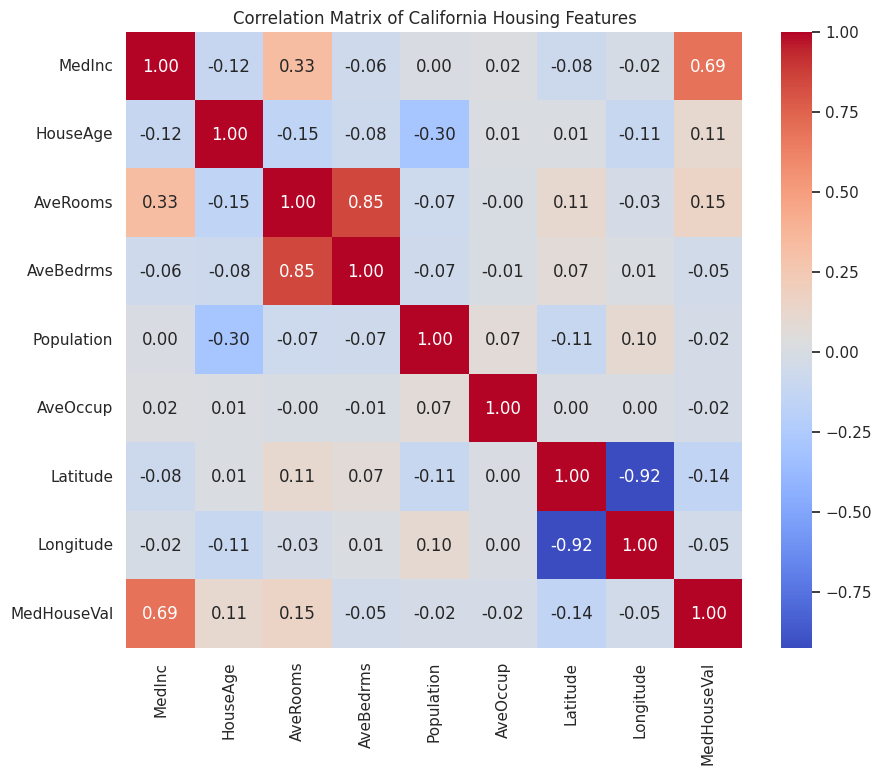

In [3]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap='coolwarm', square=True)
plt.title('Correlation Matrix of California Housing Features')
plt.show()

### Data Splitting

To evaluate our model fairly, we cannot test it on the same data it learned from. We must split the data into a **Training Set** and a **Test Set**.

In [4]:
from sklearn.model_selection import train_test_split

# Separate Features (X) and Target (y)
X = df.drop(columns=[housing_data.target.name])
y = df[housing_data.target.name]

# Split: 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")

Training samples: 16512
Testing samples: 4128


### Model Training

We will start with a **Linear Regression** model. It assumes a straight-line relationship between the input features and the house price.

In [5]:
from sklearn.linear_model import LinearRegression

# Initialize and train the model
model = LinearRegression()
model.fit(X_train, y_train)

print("Model trained successfully.")
model

Model trained successfully.


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


### Evaluation

We predict values for the Test Set and compare them to the actual values. We use ****Mean Squared Error (MSE)**** and ****$R^2$ Score**** as our metrics.

In [6]:
from sklearn.metrics import mean_squared_error, r2_score

# Generate predictions
y_pred = model.predict(X_test)

# Calculate metrics
mse = mean_squared_error(y_test, y_pred)
r2 = model.score(X_test, y_test)

print(f"MSE on test set: {mse:.2f}")
print(f"R-squared on test set: {r2:.2f}")

MSE on test set: 0.56
R-squared on test set: 0.58


### Visualization

A scatter plot of Predicted vs. Actual values helps us visually assess accuracy. A perfect model would align all points on the red line.

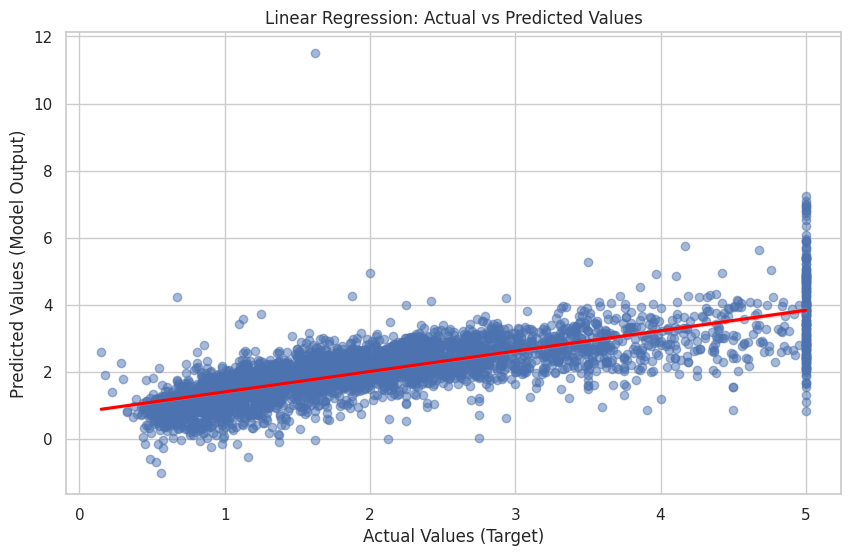

In [7]:
plt.figure(figsize=(10, 6))
sns.regplot(x=y_test, y=y_pred, 
            scatter_kws={'alpha':0.5}, 
            line_kws={'color':'red'})
plt.xlabel("Actual Values (Target)")
plt.ylabel("Predicted Values (Model Output)")
plt.title("Linear Regression: Actual vs Predicted Values")
plt.show()

Finally, we save the dataset for future modules.

In [8]:
df.to_csv('../../data/california_housing.csv', index=False)
print("California housing dataset saved.")

California housing dataset saved.


## Exercises

Now, you will apply this workflow to the ****Ames Housing dataset****. This is a more complex dataset containing 80 explanatory variables describing (almost) every aspect of residential homes in Ames, Iowa.

### Load and Inspect

-   Load the dataset using `fetch_openml`.
-   Print the number of samples and features.

In [9]:
from sklearn.datasets import fetch_openml

# 'parser="auto"' creates a more efficient pandas dataframe
ames_data = fetch_openml('house_prices', as_frame=True, parser="auto")
df_ames = ames_data.frame

print("Ames Housing Dataset Loaded")
print(f"Samples: {df_ames.shape[0]}, Features: {df_ames.shape[1] - 1}")

Ames Housing Dataset Loaded
Samples: 1460, Features: 80


### Feature Selection via Correlation

The dataset is large. To keep things simple for this exercise:

1.  Calculate correlations for numeric columns only.
2.  Select only the feature with the highest correlation to `SalePrice`.

In [10]:
# Select only numeric columns for correlation analysis
numeric_cols = df_ames.select_dtypes(include=['float64', 'int64']).columns

# Display the top 5 features most correlated with SalePrice
corr_matrix = df_ames[numeric_cols].corr()
print(corr_matrix['SalePrice'].sort_values(ascending=False).head(6))

# Based on the output, 'OverallQual' is usually the highest.
# We will subset the data to just Feature and Target to avoid NaN issues in other columns
df_simple = df_ames[['OverallQual', 'SalePrice']].dropna()

X_ames = df_simple[['OverallQual']]
y_ames = df_simple['SalePrice']

SalePrice      1.000000
OverallQual    0.790982
GrLivArea      0.708624
GarageCars     0.640409
GarageArea     0.623431
TotalBsmtSF    0.613581
Name: SalePrice, dtype: float64


### Train a Random Forest

Instead of Linear Regression, use a ****Random Forest Regressor****. This is a more powerful model capable of capturing non-linear relationships.

-   Split the data (80/20).
-   Train the model.
-   Evaluate with MSE and $R^2$.

In [11]:
from sklearn.ensemble import RandomForestRegressor

# 1. Split
X_train_a, X_test_a, y_train_a, y_test_a = train_test_split(X_ames, y_ames, test_size=0.2, random_state=42)

# 2. Train
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train_a, y_train_a)

# 3. Evaluate
y_pred_a = rf_model.predict(X_test_a)
mse_a = mean_squared_error(y_test_a, y_pred_a)
r2_a = r2_score(y_test_a, y_pred_a)

print(f"Random Forest MSE: {mse_a:,.0f}")
print(f"Random Forest R2:  {r2_a:.2f}")

Random Forest MSE: 2,140,675,155
Random Forest R2:  0.72


### Visualization

Visualize the Random Forest predictions.

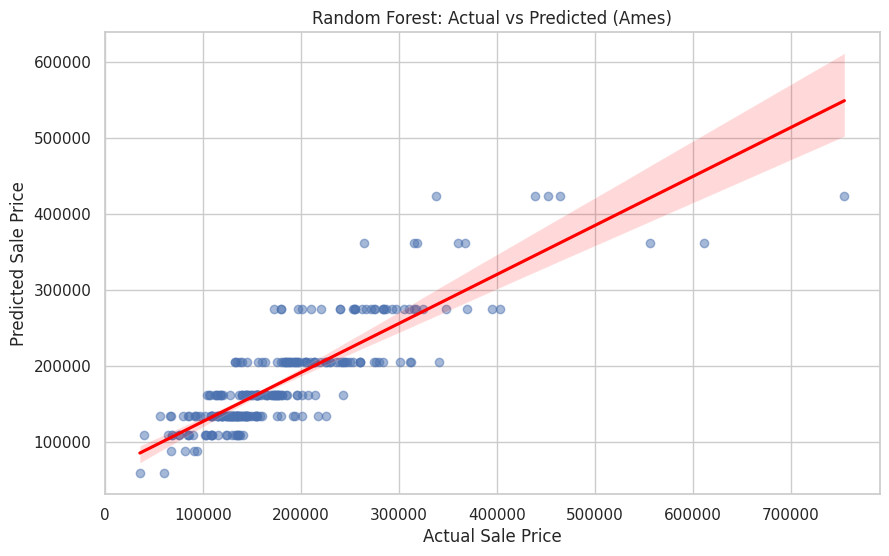

In [12]:
plt.figure(figsize=(10, 6))
sns.regplot(x=y_test_a, y=y_pred_a,
            scatter_kws={'alpha':0.5},
            line_kws={'color':'red'})
plt.xlabel("Actual Sale Price")
plt.ylabel("Predicted Sale Price")
plt.title("Random Forest: Actual vs Predicted (Ames)")
plt.show()

## Summary

In this module, we moved from theory to practice. We executed the full ****Machine Learning Workflow****:

1.  Loaded and cleaned data.
2.  Visualized relationships (Correlation).
3.  Split data to prevent overfitting.
4.  Trained two different models (Linear Regression and Random Forest).
5.  Evaluated success using standard metrics.